# Implied Correlation Signal

This notebook will focus on generating signals using implied/realized correlation within equity trend following models. 

# Packages & Paths

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [2]:
curr_path = os.getcwd()
research_path = os.path.abspath(os.path.join(curr_path, ".."))
repo_path     = os.path.abspath(os.path.join(research_path, ".."))
data_path     = os.path.join(repo_path, "data")
fut_path      = os.path.join(data_path, "FuturesData")
misc_path     = os.path.join(data_path, "MiscData")

In [3]:
tool_path = os.path.join(repo_path, "src", "Tools")
sys.path.append(tool_path)

from SignalTools import SignalAnalysis

# Getting Data

In [4]:
fut_px_path = os.path.join(fut_path, "PrepFuturesPX.parquet")
ic_px_path  = os.path.join(misc_path, "CleanedImpliedRealCorrelation.parquet")
ticker_path = os.path.join(misc_path, "ImpliedCorrelationTickerGuide.xlsx")

df_fut = (pd.read_parquet(
    path = fut_px_path, engine = "pyarrow"))

df_corr = (pd.read_parquet(
    path = ic_px_path, engine = "pyarrow").
    query("file == 'ImpliedCorr'").
    drop(columns = ["file", "clean_val"]).
    rename(columns = {
        "variable": "eq_ticker",
        "Date"    : "date"}).
    drop_duplicates())

df_corr_fut_guide = (pd.read_excel(
    io = ticker_path, sheet_name = "TickerGuide").
    rename(columns = {
        "Equity Index": "equity",
        "Future"      : "future"}).
    assign(
        equity = lambda x: x.equity.str.split(" ").str[0],
        future = lambda x: x.future.str.replace(" 1", "1").str.replace(" ", "_").str.lower()).
    dropna().
    rename(columns = {"future": "ticker"}))

In [36]:
path  = os.path.join(data_path, "Signals", "DaoNguyenDerembleLemperiereBouchaudPotters.parquet")
df_px = (pd.read_parquet(
    path = path, engine = "pyarrow").
    merge(right = df_corr_fut_guide, how = "inner", on = ["ticker"])
    [["date", "ticker", "px", "px_diff", "px_rtn"]])

In [37]:
df_scaler = (df_corr
    .assign(date = lambda x: pd.to_datetime(x.date).dt.date)
    .set_index("date")
    .groupby(["eq_ticker", "window"])
    .apply(lambda x: (x.sort_index().value + 1).diff())
    .to_frame(name = "scaler")
    .reset_index())

In [38]:
df_combined = (df_corr_fut_guide
    .merge(right = df_px, how = "inner", on = ["ticker"])
    .rename(columns = {"equity": "eq_ticker"})
    .merge(right = df_scaler, how = "inner", on = ["date", "eq_ticker"])
    .dropna())

In [56]:
df_raw_signal = (df_combined
    .assign(adj_val = lambda x: x.scaler * x.px_diff)
    [["ticker", "date", "px_diff", "window", "adj_val"]])

In [85]:
df_signal = (df_raw_signal
    .pivot(index = ["date", "ticker", "px_diff"], columns = "window", values = "adj_val")
    .reset_index()
    .set_index("date")
    .groupby("ticker")
    .apply(lambda x: x.sort_index() / x.sort_index().ewm(span = 10, adjust = False).std())
    .reset_index()
    .set_index("date")
    .groupby("ticker")
    .apply(lambda x: x.ewm(span = 100, adjust = False).mean().shift())
    .reset_index())

In [86]:
(df_signal
    .melt(id_vars = ["date", "ticker", "px_diff"])
    .drop(columns = ["date"])
    .groupby(["ticker", "window"])
    .agg("corr")
    .loc[lambda x: x.value != 1]
    .reset_index()
    .dropna()
    .pivot(index = "ticker", columns = "window", values = "value"))

window,OneMonth,OneYear,SixMonth,ThreeMonth
ticker,,,,
cf1_index,0.268046,0.226772,0.259381,0.295696
dm1_index,0.247358,0.072561,0.182433,0.194322
eo1_index,0.289896,0.303611,0.266557,0.272730
es1_index,0.205860,0.206297,0.260156,0.215451
gx1_index,0.335248,0.178273,0.308009,0.323090
hi1_index,-0.533414,-0.428219,-0.259689,-0.479569
ib1_index,0.702634,0.394433,0.342712,0.455102
nk1_index,-0.544676,-0.053070,NaN,-0.780215
nq1_index,0.093702,0.138883,0.087320,0.056462


In [90]:
df_signal_rtn = (df_signal
    .melt(id_vars = ["date", "ticker"], value_name = "signal")
    .merge(right = df_px, how = "inner", on = ["date", "ticker"])
    .assign(signal_rtn = lambda x: x.signal * x.px_rtn))

In [101]:
df_vol_rtn = (df_signal_rtn
    .assign(tmp = lambda x: x.ticker + "-" + x.window)
    .pivot(index = "date", columns = "tmp", values = "signal_rtn")
    .apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))))

df_cuml = (df_vol_rtn
    .rolling(window = 50)
    .sum()
    .reset_index()
    .melt(id_vars = "date", value_name = "cuml_rtn")
    .dropna())

In [113]:
df_signal_vol = (df_vol_rtn
    .reset_index()
    .melt(id_vars = "date", value_name = "vol_rtn")
    .dropna()
    .merge(right = df_cuml, how = "inner", on = ["date", "tmp"]))

In [128]:
df_combined = (df_signal
    .melt(id_vars = ["date", "ticker"])
    .dropna()
    .assign(tmp = lambda x: x.ticker + "-" + x.window)
    .merge(right = df_signal_vol, how = "inner", on = ["date", "tmp"]))

<Axes: xlabel='value', ylabel='cuml_rtn'>

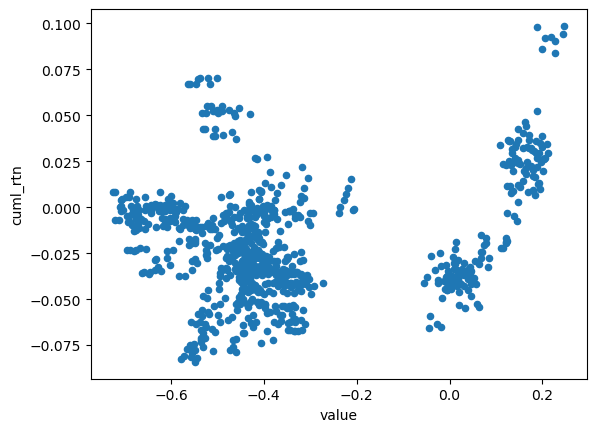

In [129]:
(df_combined
    .loc[lambda x: x.ticker == "es1_index"]
    .plot(kind = "scatter", x = "value", y = "cuml_rtn"))

In [6]:
asd

NameError: name 'asd' is not defined

In [ ]:
df_tmp_corr = (df_corr
    .loc[lambda x: x.eq_ticker == "SPX"]
    .loc[lambda x: x.window == x.window.min()]
    .assign(date = lambda x: pd.to_datetime(x.date).dt.date)
    .set_index("date")
    [["value"]])

In [ ]:
df_tmp = (df_prep
    .loc[lambda x: x.ticker == "es1_index"]
    .set_index("date")
    .merge(right = df_tmp_corr, how = "inner", on = ["date"])
    [["px", "px_diff", "value"]]
    .rename(columns = {"value": "corr_val"}))

In [ ]:
df_signal = (df_tmp
    .assign(adj_diff = lambda x: (1 + x.corr_val.diff()) * x.px_diff)
    .drop(columns = ["px", "corr_val"])
    .apply(lambda x: x / x.ewm(span = 100, adjust = False).std())
    .apply(lambda x: x.ewm(span = 100, adjust = False).mean().shift())
    .reset_index()
    .melt(id_vars = "date"))

In [ ]:
df_signal.pivot(index = "date", columns = "variable", values = "value").corr()

In [ ]:
df_signal_rtn = (df_tmp
    [["px"]]
    .pct_change()
    .merge(right = df_signal, how = "inner", on = ["date"])
    .assign(signal_rtn = lambda x: x.value * x.px))

In [ ]:
df_vol_rtn = (df_signal_rtn
    .pivot(index = "date", columns = "variable", values = "signal_rtn")
    .apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))))

df_cuml = (df_vol_rtn
    .rolling(window = 50)
    .sum()
    .reset_index()
    .melt(id_vars = "date")
    .dropna())

In [ ]:
df_tmp = (df_vol_rtn
    .reset_index()
    .melt(id_vars = "date", value_name = "vol_rtn")
    .dropna()
    .merge(right = df_cuml, how = "inner", on = ["date", "variable"])
    .rename(columns = {"value": "cuml_rtn"})
    .merge(right = df_signal, how = "inner", on = ["date", "variable"]))

In [ ]:
(df_tmp
    .pivot(index = "date", columns = "variable", values = "value")
    .corr())

In [ ]:
(df_combined.loc[lambda x: x.variable == x.variable.min()]).plot(kind = "scatter", x = "signal", y = "cuml_rtn")

In [ ]:
(df_combined
    [["date", "vol_rtn"]]
    .groupby("date")
    .agg("mean"))

In [ ]:

    .rename(columns = {"value": "corr_val"})
    .assign(
        adj_diff = lambda x: x.px_diff * x.corr_val,
        R        = lambda x: x.adj_diff / x.adj_diff.ewm(span = 10, adjust = False).std(),
        signal   = lambda x: x.R.ewm(span = 100, adjust = False).mean().shift(),
        px_rtn   = lambda x: x.px.pct_change(),
        signal_rtn = lambda x: x.signal * x.px_rtn,
        vol_rtn    = lambda x: x.signal_rtn * (0.1 / (x.signal_rtn.ewm(span = 100, adjust = False).std() * np.sqrt(252))),
        cuml_rtn   = lambda x: x.vol_rtn.rolling(window = 50).sum())
    .reset_index()
    .assign(year = lambda x: pd.to_datetime(x.date).dt.year)
    .loc[lambda x: x.year != x.year.min()]
    .plot(kind = "scatter", x = "signal", y = "cuml_rtn")

In [ ]:
(df_prep
    .loc[lambda x: x.ticker == "es1_index"]
    .set_index("date")
    .merge(right = df_tmp, how = "inner", on = ["date"])
    .assign(
        tmp = lambda x: (1 +x.value) * x.R,
        signal = lambda x: x.tmp.ewm(span = 100, adjust = False).mean().shift(),
        new_rtn = lambda x: x.signal * x.px_rtn,
        vol_rtn = lambda x: x.new_rtn * (0.1 / (x.new_rtn.ewm(span = 100, adjust = False).std() * np.sqrt(252))))
    [["tmp", "vol_rtn"]]
    .assign(vol_rtn = lambda x: x.vol_rtn.rolling(window = 50).sum())
    .plot(kind = "scatter", x = "tmp", y = "vol_rtn"))

# Generic Trend Following Model across various Equity Index Futures

Start by creating a generic trend following model using a 100d EWMA signal. For the most part we'll be using the signal construction from *Dao et al. (2016)*

The signal construction follows 
\begin{equation}
R_t = \frac{D_t}{\sigma_{\tau_{\sigma}} \cdot \gamma}
\end{equation}
The overall goal is to get unit variance and to handle some of the heteroskedasticity. In this case we'll use a slight modification to rewite it as 
\begin{equation}
R_t = \frac{\tilde{D}_t}{\sigma_{\tau_{\sigma}} \cdot \gamma} \;\textrm{where} \; \tilde{D}_t = \frac{D_t}{IC}
\end{equation}

In [ ]:
def _get_corr_scaled_trend(df: pd.DataFrame, trend_window: int = 180, vol_window: int = 10) -> pd.DataFrame: 

    df_out = (df.sort_values(
        "date").
        assign(
            dpx_corr   = lambda x: x.px_diff / x.value,
            vol        = lambda x: x.dpx_corr.ewm(span = vol_window, adjust = False).std(),
            dt         = lambda x: x.dpx_corr / x.vol,
            signal     = lambda x: x.dt.ewm(span = trend_window, adjust = False).mean(),
            lag_signal = lambda x: x.signal.shift()))

    return df_out 

trend_window = 180
vol_window   = 10 

df_signal = (df_prep
    [["date", "px_diff", "px_rtn", "ticker", "equity"]].
    rename(columns = {"equity": "eq_ticker"}).
    assign(date = lambda x: pd.to_datetime(x.date)).
    merge(right = df_corr, how = "inner", on = ["date", "eq_ticker"]).
    rename(columns = {"window": "corr_tenor"}).
    assign(group_var = lambda x: x.eq_ticker + " " + x.corr_tenor).
    groupby("group_var").
    apply(_get_corr_scaled_trend, trend_window, vol_window).
    reset_index().
    drop(columns = ["level_1"]))

In [ ]:
def _get_signature_baseline_signature(df: pd.DataFrame) -> pd.DataFrame: 

    input_val = df.R
    df_out    = SignalAnalysis().signature_volatility(input_val)
    return df_out

df_baseline_vol_signature = (df_prep.groupby(
    "equity").
    apply(_get_signature_baseline_signature).
    reset_index().
    drop(columns = ["level_1"]))

In [ ]:
def _get_signature_plot(df: pd.DataFrame) -> pd.DataFrame: 

    input_val = df.dt
    df_out    = SignalAnalysis().signature_volatility(input_val)
    return df_out


df_vol_plot = (df_signal.groupby(
    "group_var").
    apply(_get_signature_plot).
    reset_index().
    drop(columns = ["level_1"]).
    assign(
        security = lambda x: x.group_var.str.split(" ").str[0],
        tenor    = lambda x: x.group_var.str.split(" ").str[1]))

In [ ]:
tickers = df_vol_plot.security.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = 4, nrows = 4, figsize = (20,15))

for ticker, ax in zip(tickers, axes.flatten()): 

    df_tmp_baseline = (df_baseline_vol_signature.query(
        "equity == @ticker").
        rename(columns = {"signature": "Baseline"})
        [["tau", "Baseline"]])

    (df_vol_plot.query(
        "security == @ticker").
        rename(columns = {"tenor": ""}).
        pivot(index = "tau", columns = "", values = "signature").
        merge(right = df_tmp_baseline, how = "inner", on = ["tau"]).
        set_index("tau").
        plot(
            ax     = ax,
            ylabel = r"$\sigma^2(\tau)/ \sigma^2$",
            title  = ticker + " Index"))

fig.suptitle("Volatility Signature Plot of $\tilde{D}_t$ implied correlation scaled differenced prices")
plt.tight_layout()

For the most part we wouldn't expect the implied correlation trend following portfolio to be trendier than what we would already see with the Dao Trend portfolio. There isn't an exact way or agreed upon way of measuring the convexity of trend following returns but for now we'll use OLS of the cumulative returns of $\tau' \sim \frac{\tau}{2}$ and then regress that against our signal for against $D_t$ and $D_t^2$. Regardless of model selection from a comparative analysis standpoint we should be able to ascertain whether our convexity measure is more or less convex. There is a chance that model selection mispsecifies the relative convexity measuremet, although it'd be highly circumstantial. 

In [ ]:
def _measure_convexity(df: pd.DataFrame, trend_window: int = 180) -> pd.DataFrame: 

    df_input = (df.set_index(
        "date").
        sort_index().
        assign(cuml_rtn = lambda x: x.weight_rtn.rolling(window = trend_window // 2).sum()).
        dropna())

    model = (sm.OLS(
        endog = df_input.cuml_rtn,
        exog  = sm.add_constant(df_input[["R", "R2"]])).
        fit(
            cov_type = "HAC",
            cov_kwds = {"maxlags": 5}))

    df_param   = model.params.to_frame(name = "param_val").reset_index()
    df_pvalues = model.pvalues.to_frame(name = "pvalue").reset_index()
    df_tvalues = model.tvalues.to_frame(name = "tvalue").reset_index()

    df_out = (df_param.merge(
        right = df_pvalues, how = "inner", on = ["index"]).
        merge(right = df_tvalues, how = "inner", on = ["index"]).
        rename(columns = {"index": "param"}))

    return df_out
    
df_baliseline_param = (df_prep.assign(
    R2         = lambda x: x.R ** 2,
    weight_rtn = lambda x: x.signal_rtn * x.weight).
    dropna().
    groupby("equity").
    apply(_measure_convexity).
    reset_index().
    drop(columns = ["level_1"]))

In [ ]:
def _get_weight(df: pd.DataFrame, window: int, target: float) -> pd.DataFrame: 

    df_out = (df.assign(
        R          = lambda x: x.px_diff / x.px_diff.ewm(span = 10, adjust = False).std(),
        signal_rtn = lambda x: x.lag_signal * x.px_rtn,
        weight_rtn = lambda x: x.signal_rtn * (target / (x.signal_rtn.ewm(span = window, adjust = False).std()))).
        dropna())

    return df_out

window = 100
target = 0.01

df_weight_rtn = (df_signal.set_index(
    "date").
    groupby("group_var").
    apply(_get_weight, window, target).
    reset_index())

In [ ]:
df_corr_params = (df_weight_rtn.assign(
    R2 = lambda x: x.dt ** 2).
    groupby("group_var").
    apply(_measure_convexity).
    reset_index().
    drop(columns = ["level_1"]))

In [ ]:
df_corr_longer = (df_corr_params.query(
    "param == 'R2'").
    drop(columns = ["param"]).
    assign(
        eq_ticker = lambda x: x.group_var.str.split(" ").str[0],
        tenor     = lambda x: x.group_var.str.split(" ").str[1]).
    drop(columns = ["group_var"]).
    melt(id_vars = ["eq_ticker", "tenor"]))

In [ ]:
df_baseline_longer = (df_baliseline_param.query(
    "param == 'R2'").
    drop(columns = ["param"]).
    melt(id_vars = "equity").
    rename(columns = {"equity": "eq_ticker"}).
    assign(tenor = "baseline"))

In [ ]:
df_baseline_longer = df_baseline_longer.assign(tenor="Baseline")
df_param_combined  = pd.concat([df_corr_longer, df_baseline_longer])

out = (
    df_param_combined
    .rename(columns={
        "variable" : "",
        "eq_ticker": "Eq. Ticker",
        "tenor"    : "Tenor"})
    .replace({
        "param_val": "Param. Val",
        "pvalue"   : "$p$-value",
        "tvalue"   : "$t$-value"})
    .pivot(
        index   = "Eq. Ticker",
        columns = ["", "Tenor"],
        values  = "value",
    )
)
display(out)

In [ ]:
(df_param_combined.query(
    "variable == 'param_val'").
    rename(columns = {"tenor": ""}).
    pivot(index = "eq_ticker", columns = "", values = "value").
    sort_values("Baseline").
    plot(
        figsize = (9,5),
        kind   = "bar",
        ylabel = r"$\beta$ for $D_t^2$",
        xlabel = "",
        title  = r"Comparing Trend Convexity of Implied Correlation Trend to Baseline Trend Performance" + "\n" + r"Using $\beta$ of $D_t^2$ controlling for $D_t$ (Not accounting for Statistical Signficance)"))

plt.show()

Controlling for statistical signficance (using |1.2| for t-value and 0.1 for p-value, which is consistent with some literature) and then comparing it to their benchmark trend convexity only HSI equity futures are more convex than the baseline. Which follows in line with the expectation of the volatility signature plot. 

In [ ]:
(df_param_combined.pivot(
    index = ["eq_ticker", "tenor"], columns = "variable", values = "value").
    assign(stat_sig = lambda x: (x.pvalue < 0.1) & (np.abs(x.tvalue) > 1.2)).
    reset_index().
    query("stat_sig == True")
    [["eq_ticker", "tenor", "param_val"]].
    pivot(index = "eq_ticker", columns = "tenor", values = "param_val").
    reset_index().
    melt(id_vars = ["eq_ticker", "Baseline"]).
    dropna().
    assign(more_convex = lambda x: x.value > x.Baseline).
    rename(columns = {
        "eq_ticker"  : "Equity Ticker",
        "Baseline"   : "Baseline Convexity",
        "tenor"      : "Correlation Tenor",
        "value"      : "Corr Convexity",
        "more_convex": "More Convex"}))

Now to compare the returns, before doing so we have to account that some securities have more implied correlation measurement than others. Therefore we'll control for both of those. We'll specify using equal asset and equal signal. 

In [ ]:
df_equal_signal = (df_weight_rtn[
    ["date", "weight_rtn"]].
    groupby("date").
    agg("mean").
    rename(columns = {"weight_rtn": "eq_signal"}))

In [ ]:
df_equal_asset = (df_weight_rtn[
    ["date", "eq_ticker", "weight_rtn"]].
    groupby(["date", "eq_ticker"]).
    agg("mean").
    reset_index().
    drop(columns = ["eq_ticker"]).
    groupby("date").
    agg("mean").
    rename(columns = {"weight_rtn": "eq_asset"}))

In [ ]:
df_baseline = (df_prep.assign(
    date         = lambda x: pd.to_datetime(x.date),
    weighted_rtn = lambda x: x.weight * x.signal_rtn)
    [["date", "weighted_rtn"]].
    groupby("date").
    agg("mean").
    rename(columns = {"weighted_rtn": "baseline"}).
    dropna())

In [ ]:
df_equal_combined = (df_equal_signal.merge(
    right = df_equal_asset, how = "inner", on = ["date"]).
    merge(right = df_baseline, how = "inner", on = ["date"]))

In [ ]:
df_combined_prep = (df_equal_combined.rename(columns = {
    "eq_signal": "Equal Signal",
    "eq_asset" : "Equal Asset",
    "baseline" : "Baseline"}))

In [ ]:
(df_combined_prep.apply(
    lambda x: np.cumprod(1 + x)).
    plot(
        logy    = True,
        ylabel  = "Cuml. Ret. Log-Scaled",
        title   = "Cumulative Returns of Portfolios",
        figsize = (8,5)))

plt.show()

In [ ]:
fig, axes = plt.subplots(ncols = 2, figsize = (16,5))

(df_combined_prep.agg(
    lambda x: x.mean() / x.std() * np.sqrt(252)).
    to_frame(name = "sharpe").
    sort_values("sharpe").
    plot(
        kind   = "bar",
        legend = False,
        rot    = 0,
        ylabel = "Ann. Sharpe",
        ax     = axes[0],
        title  = "Annualized Sharpe"))

sns.heatmap(
    data  = df_combined_prep.corr(),
    ax    = axes[1],
    annot = True,
    cbar  = False)

axes[1].set_title("Correlation Matrix")
plt.show()

In [ ]:
def _get_params(df: pd.DataFrame) -> pd.DataFrame:

    model = (sm.OLS(
        endog = df.value,
        exog  = sm.add_constant(df.Baseline)).
        fit(
            cov_type = "HAC",
            cov_kwds = {"maxlags": 5}))

    df_param   = model.params.to_frame(name = "param_val").reset_index()
    df_pvalues = model.pvalues.to_frame(name = "pvalue").reset_index()
    df_tvalues = model.tvalues.to_frame(name = "tvalue").reset_index()

    df_out = (df_param.merge(
        right = df_pvalues, how = "inner", on = ["index"]).
        merge(right = df_tvalues, how = "inner", on = ["index"]).
        rename(columns = {"index": "param"}))

    return df_out

df_params = (df_combined_prep.reset_index().melt(
    id_vars = ["date", "Baseline"]).
    drop(columns = ["date"]).
    groupby("variable").
    apply(_get_params).
    reset_index().
    drop(columns = ["level_1"]))

In [ ]:
(df_params.rename(columns = {
    "variable" : "Exog",
    "param"    : "Param Name",
    "param_val": "Param Val",
    "pvalue"   : "$p$-value",
    "tvalue"   : "$t$-value"}))

# References

Dao, T.-L., Nguyen, T.-T., Deremble, C., Lempérière, Y., Bouchaud, J.-P., & Potters, M. (2016). *Tail protection for long investors: Trend convexity at work*. arXiv:1607.02410. https://doi.org/10.48550/arXiv.1607.02410